<a href="https://colab.research.google.com/github/pavithiras1212/EDA/blob/dev/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from scipy.cluster.hierarchy import dendrogram, linkage
from pandas.plotting import parallel_coordinates, andrews_curves
import plotly.express as px

# Set modern visualization parameters
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'figure.titlesize': 13})

In [6]:
# -------------------------------------------------------------
# 1. FETCH THE DATASET VIA OFFLINE LOCAL SIMULATION
# -------------------------------------------------------------
np.random.seed(42)
n_samples = 300

# Generating a self-contained local DataFrame matching all required EDA structures
df = pd.DataFrame({
    'Revenue': np.random.exponential(scale=5000, size=n_samples) + 1000,
    'Customer_Retention': np.random.uniform(50, 98, size=n_samples),
    'Margin_Pct': np.random.uniform(15, 45, size=n_samples),
    'cut': np.random.choice(['Ideal', 'Premium', 'Very Good', 'Good', 'Fair'], size=n_samples),
    'State': np.random.choice(['CA', 'TX', 'NY', 'FL', 'IL', 'PA', 'OH', 'GA', 'NC', 'MI'], size=n_samples),
    'Store_Tier': np.random.choice(['Premium', 'Standard'], size=n_samples, p=[0.4, 0.6]),
    'Feedback': np.random.choice(["Excellent", "Fast Shipping", "Quality", "Support", "Reliable", "Defective", "Bad", "Awesome", "Great"], size=n_samples)
})

# Add variables with strong correlation for scatter/heatmap matching
df['Marketing_Spend'] = df['Revenue'] * 0.15 + np.random.normal(0, 200, size=n_samples)
df['Net_Profit'] = df['Revenue'] * 0.25 + np.random.normal(0, 150, size=n_samples)


In [10]:
# -------------------------------------------------------------
# 1. FETCH THE DATASET VIA OFFLINE LOCAL SIMULATION
# -------------------------------------------------------------
np.random.seed(42)
n_samples = 300

# Generating a self-contained local DataFrame matching all required EDA structures
df = pd.DataFrame({
    'Revenue': np.random.exponential(scale=5000, size=n_samples) + 1000,
    'Customer_Retention': np.random.uniform(50, 98, size=n_samples),
    'Margin_Pct': np.random.uniform(15, 45, size=n_samples),
    'cut': np.random.choice(['Ideal', 'Premium', 'Very Good', 'Good', 'Fair'], size=n_samples),
    'State': np.random.choice(['CA', 'TX', 'NY', 'FL', 'IL', 'PA', 'OH', 'GA', 'NC', 'MI'], size=n_samples),
    'Store_Tier': np.random.choice(['Premium', 'Standard'], size=n_samples, p=[0.4, 0.6]),
    'Feedback': np.random.choice(["Excellent", "Fast Shipping", "Quality", "Support", "Reliable", "Defective", "Bad", "Awesome", "Great"], size=n_samples),
    'Marketing_Spend': np.random.uniform(100, 1000, size=n_samples),
    'Net_Profit': np.random.uniform(50, 800, size=n_samples)
})


In [8]:
def plot_pie(data, labels, title="Pie Chart"):
    """Plots a traditional proportional pie chart."""
    plt.figure(figsize=(7, 7))
    plt.pie(data, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Pastel1"))
    plt.title(title, pad=20, weight='bold')
    plt.tight_layout()
    plt.show()

def plot_bar(categories, values, title="Bar Chart"):
    """Plots a category comparison bar chart."""
    plt.figure(figsize=(8, 5))
    sns.barplot(x=categories, y=values, palette="muted", hue=categories, legend=False)
    plt.title(title, pad=15, weight='bold')
    plt.xlabel("Categories")
    plt.ylabel("Values")
    plt.tight_layout()
    plt.show()

def plot_histogram(df, column):
    """Plots a numerical frequency frequency distribution."""
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], kde=True, color="skyblue", bins=20)
    plt.title(f"Distribution of {column}", pad=15, weight='bold')
    plt.xlabel(column)
    plt.ylabel("Frequency Count")
    plt.tight_layout()
    plt.show()

def scatter(x, y):
    """Plots standard bivariate coordinate dimensions."""
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=x, y=y, color="purple", alpha=0.7)
    plt.title(f"{x.name} vs. {y.name}", pad=15, weight='bold')
    plt.xlabel(x.name)
    plt.ylabel(y.name)
    plt.tight_layout()
    plt.show()

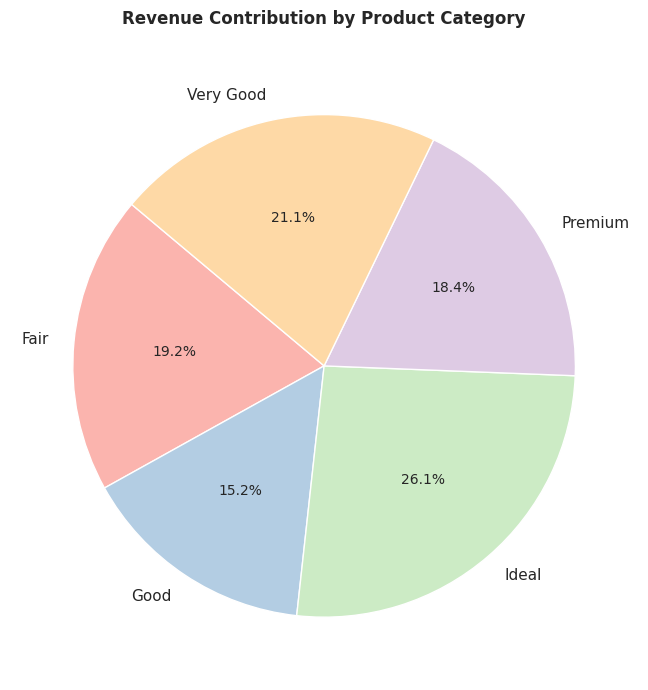

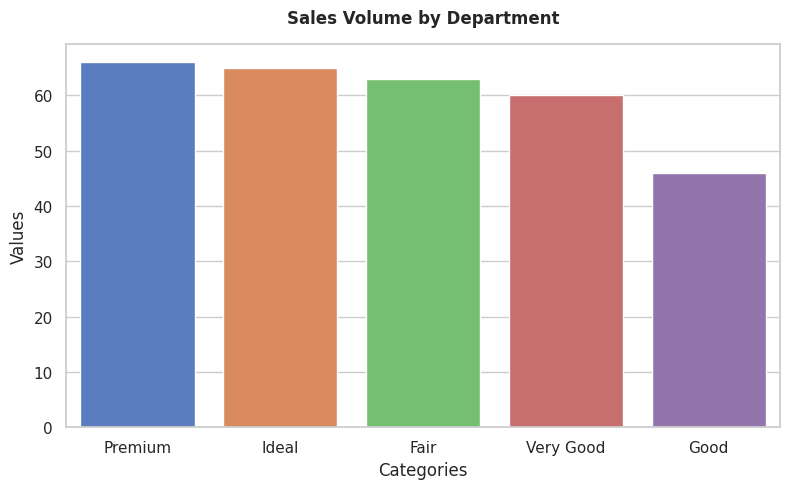

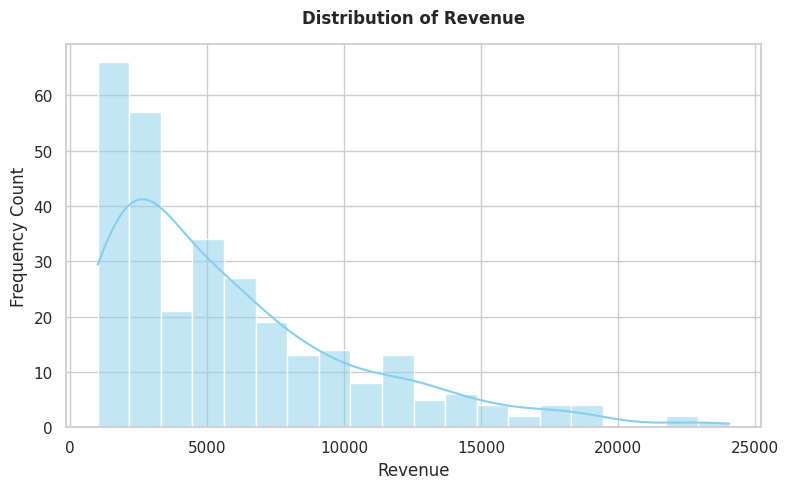

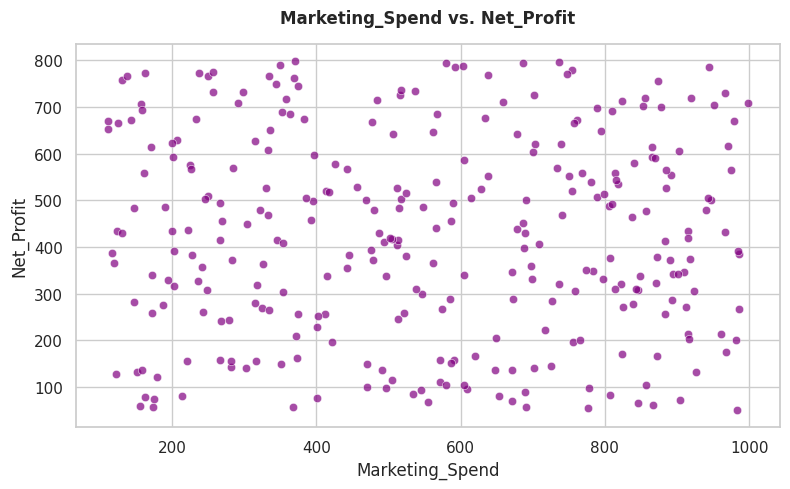

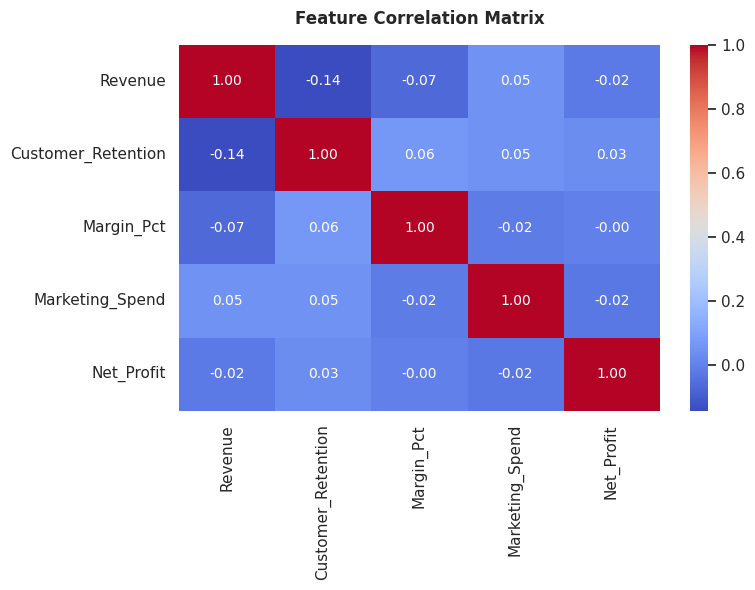

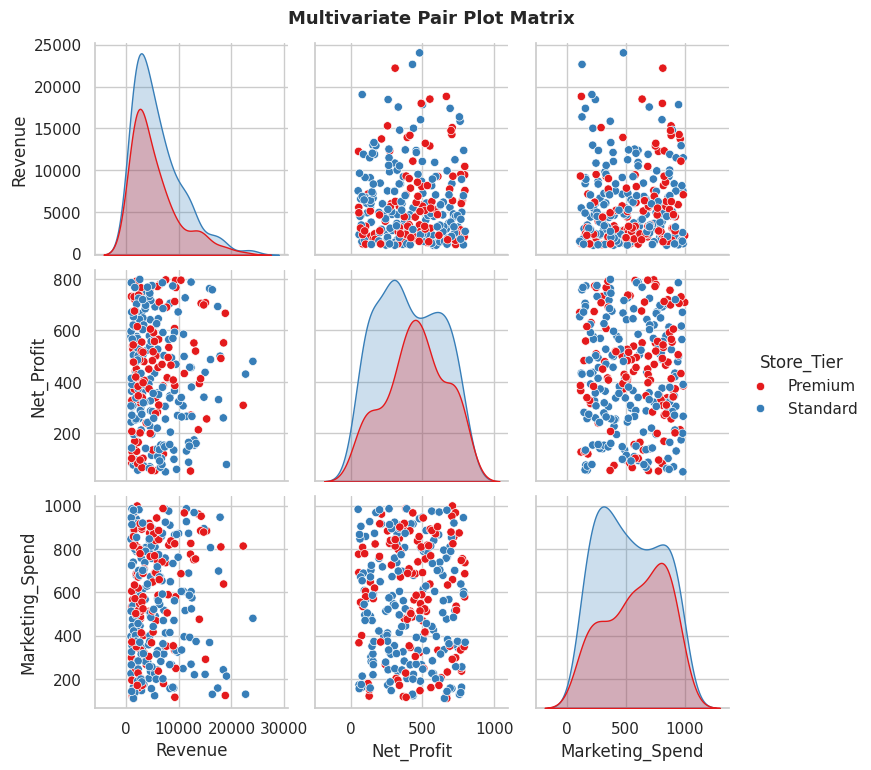

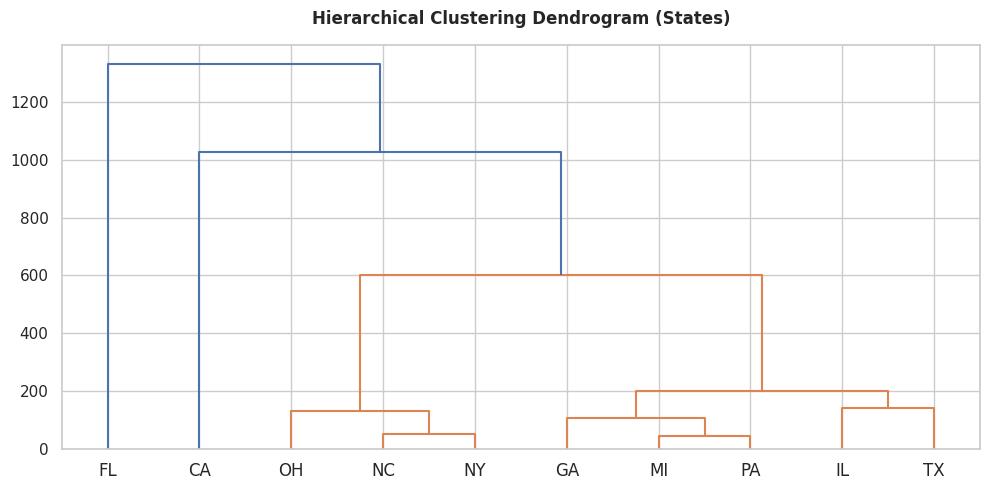

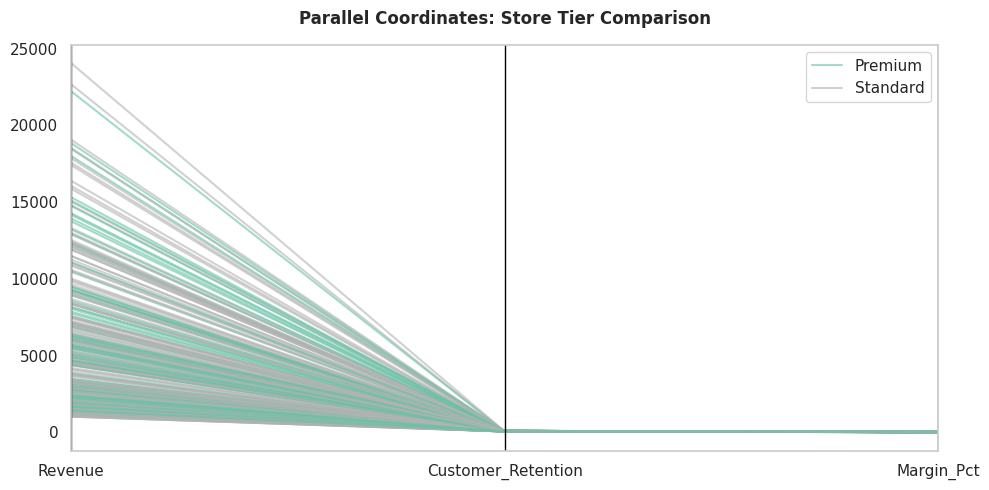

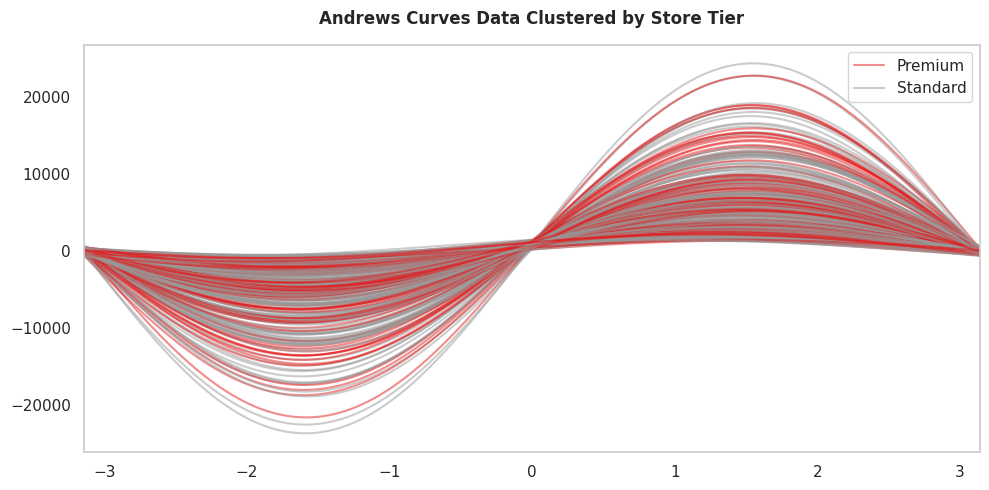

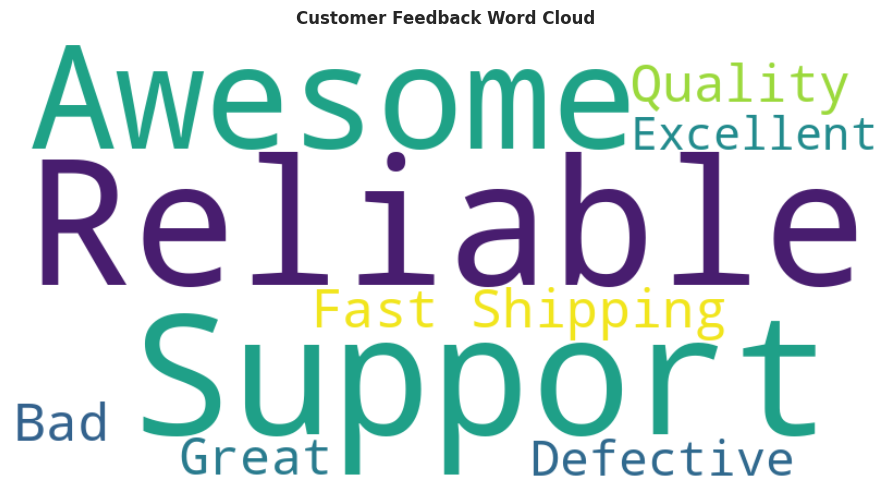

In [11]:
# 3. EXECUTE EDA CODES
# -------------------------------------------------------------

# --- 1. PIE CHART ---
revenue_split = df.groupby('cut')['Revenue'].sum()
plot_pie(data=revenue_split.values, labels=revenue_split.index, title="Revenue Contribution by Product Category")

# --- 2. BAR CHART ---
cat_counts = df['cut'].value_counts()
plot_bar(categories=cat_counts.index, values=cat_counts.values, title="Sales Volume by Department")

# --- 3. HISTOGRAM ---
plot_histogram(df, 'Revenue')

# --- 4. SCATTER PLOT ---
scatter(df['Marketing_Spend'], df['Net_Profit'])

# --- 5. CORRELATION HEATMAP ---
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix", pad=15, weight='bold')
plt.tight_layout()
plt.show()

# --- 6. PAIR PLOTS ---
pairplot_fig = sns.pairplot(df[['Revenue', 'Net_Profit', 'Marketing_Spend', 'Store_Tier']], hue='Store_Tier', palette='Set1')
pairplot_fig.fig.suptitle("Multivariate Pair Plot Matrix", y=1.02, weight='bold')
plt.show()

# --- 7. DENDROGRAMS ---
cluster_data = df.groupby('State')[['Revenue', 'Net_Profit', 'Marketing_Spend']].mean()
linked = linkage(cluster_data, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, labels=cluster_data.index)
plt.title("Hierarchical Clustering Dendrogram (States)", pad=15, weight='bold')
plt.tight_layout()
plt.show()

# --- 8. PARALLEL COORDINATE PLOTS ---
plt.figure(figsize=(10, 5))
parallel_df = df[['Revenue', 'Customer_Retention', 'Margin_Pct', 'Store_Tier']].copy()
parallel_coordinates(parallel_df, class_column='Store_Tier', colormap='Set2', alpha=0.6)
plt.title("Parallel Coordinates: Store Tier Comparison", pad=15, weight='bold')
plt.tight_layout()
plt.show()

# --- 9. ANDREWS CURVES ---
plt.figure(figsize=(10, 5))
andrews_df = df[['Marketing_Spend', 'Revenue', 'Net_Profit', 'Store_Tier']]
andrews_curves(andrews_df, class_column='Store_Tier', colormap='Set1', alpha=0.5)
plt.title("Andrews Curves Data Clustered by Store Tier", pad=15, weight='bold')
plt.tight_layout()
plt.show()

# --- 10. WORD CLOUD ---
text_combined = " ".join(review for review in df['Feedback'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Customer Feedback Word Cloud", pad=15, weight='bold')
plt.tight_layout()
plt.show()

# --- 11. CHOROPLETH MAP (Plotly Express) ---
state_revenue = df.groupby('State')['Revenue'].sum().reset_index()
fig = px.choropleth(
    state_revenue,
    locations='State',
    locationmode="USA-states",
    color='Revenue',
    scope="usa",
    color_continuous_scale="Viridis",
    title="Regional Sales Performance across United States"
)
fig.show()